# Classification Perfomance based on Explanations

In [ ]:
import sys
import os
import pandas as pd
import matplotlib.pyplot as plt
from os.path import join, abspath
from collections import Counter
import numpy as np
from os.path import join
sys.path.append("../..")


from config import DATA_DIR, ALL_GROUPS
from utils.classification_helpers import group_ihra_content, group_lexicon_content, map_lexicon_chapters_to_ihra_sections, flatten, count_items, compute_multilabel_prec_recall, plot_distribution_diff, plot_distribution_diff_pair

In [2]:
PROVIDER = "llama"

In [3]:
bloomington = pd.read_feather(join(DATA_DIR, f"{PROVIDER}_bloomington_label_1.feather"))
decoding = pd.read_feather(join(DATA_DIR, f"{PROVIDER}_decoding_label_1.feather"))

In [4]:

column_name_renaming = {
    'classification_ihra_explanation_cleaned': 'IHRA_c',
    'explanation_ihra_explanation_cleaned': 'IHRA_e',
    'classification_tax': 'TAX_c',
    'explanation_tax': 'TAX_e',
    'classification_tax_ex': 'TAX_EX_c',
    'explanation_tax_ex': 'TAX_EX_e',

    'explanation_ihra_explanation_sections': 'IHRA_e_sections',
    'explanation_tax_chapters': 'TAX_e_chapters',
    'explanation_tax_chapters_no': 'TAX_e_chapters_no',
    'explanation_tax_ex_chapters': 'TAX_EX_e_chapters',
    'explanation_tax_ex_chapters_no': 'TAX_EX_e_chapters_no',
    'explanation_tax_sections': 'TAX_e_sections',
    'explanation_tax_ex_sections': 'TAX_EX_e_sections',
}
bloomington.rename(columns=column_name_renaming, inplace=True)
decoding.rename(columns=column_name_renaming, inplace=True)

REL_CLASS_COLS = column_name_renaming.values()

BLOOMINGTON_DATA_COLS = ['comment_cleaned', 'keyword', 'ihra_sections']
DECODING_DATA_COLS = ['comment_cleaned', 'comment_codes_all_list', 'comment_codes_all_chapters', 'comment_codes_all_sections']

ALL_GROUPS = {'classic_power', 'aggressive', 'second_postholocaust', 'israel'}

# Bloomington

### IHRA

In [10]:
bloomington_ihra = bloomington[bloomington['IHRA_c']=='Yes'][BLOOMINGTON_DATA_COLS + ['IHRA_e', 'IHRA_e_sections']]
bloomington_ihra["ihra_sections"] = bloomington_ihra["ihra_sections"].map(lambda x: [i for i in x if i!=13])  # Remove section 13 as it is not part of the IHRA definition (errors in section-level annotations)
bloomington_ihra['annotators_content_groups'] = bloomington_ihra['ihra_sections'].apply(lambda x: list(set([group_ihra_content(item) for item in x])))
bloomington_ihra['explanation_content_groups'] = bloomington_ihra['IHRA_e_sections'].apply(lambda x: list(set([group_ihra_content(item) for item in x])))

In [11]:
len(bloomington_ihra)

1252

In [12]:
bloomington_ihra['overlap'] = bloomington_ihra.apply(
    lambda row: 1 if set(row['annotators_content_groups']) & set(row['explanation_content_groups']) else 0,
    axis=1
)
bloomington_ihra['overlap'].mean()

np.float64(0.8777955271565495)

#### Group level

In [ ]:
bloomington_ihra['explanation_same_content_groups'] = bloomington_ihra['IHRA_e_sections_same'].apply(lambda x: list(set([group_ihra_content(item) for item in x])))

In [ ]:
b_ihra_groups_count, b_ihra_groups_count_norm = count_items(bloomington_ihra["annotators_content_groups"], interpret_as_int=False)
b_ihra_e_groups_count, b_ihra_e_groups_count_norm = count_items(bloomington_ihra["explanation_content_groups"], interpret_as_int=False)
b_ihra_e_groups_same_count, b_ihra_e_groups_same_count_norm = count_items(bloomington_ihra["explanation_same_content_groups"], interpret_as_int=False)

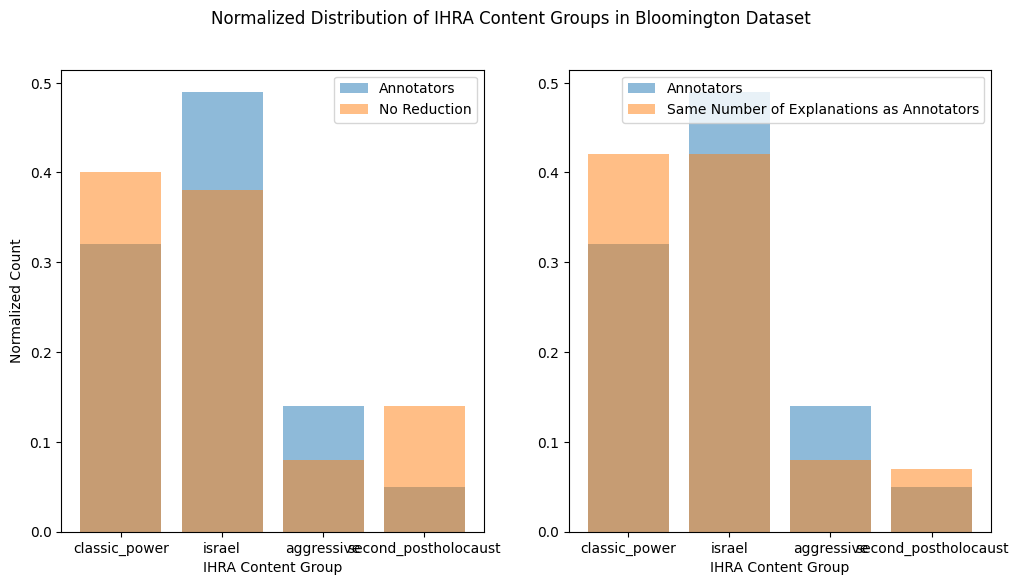

In [33]:
plot_distribution_diff_pair(
    b_ihra_groups_count_norm,
    b_ihra_e_groups_count_norm,
    b_ihra_e_groups_same_count_norm,
    'No Reduction',
    'Same Number of Explanations as Annotators',
    'Normalized Distribution of IHRA Content Groups in Bloomington Dataset',
    'IHRA Content Group',
    normalized=True)

In [35]:
len(bloomington_ihra[bloomington_ihra["overlap"]==1])/len(bloomington_ihra)

0.8777955271565495

Calculate recall (how often did the model correctly identify a specific content group that was labeled by annotators) as well as precision (how often did the model correctly name the content group as an explanation of a post being antisemitic)

In [36]:
compute_multilabel_prec_recall(bloomington_ihra, 'annotators_content_groups', 'explanation_content_groups')

,content_group,annotators_identified,model_identified,both_identified,recall,precision
0,aggressive,206,144,73,0.354369,0.506944
3,classic_power,493,749,413,0.837728,0.551402
2,israel,736,714,654,0.888587,0.915966
1,second_postholocaust,82,271,49,0.597561,0.180812


### TAX

In [40]:
bloomington_tax = bloomington[bloomington['TAX_c']=='Yes'][BLOOMINGTON_DATA_COLS + ['TAX_e_chapters']]
bloomington_tax['annotators_content_groups'] = bloomington_tax['ihra_sections'].apply(lambda x: list(set([group_ihra_content(item) for item in x])))
bloomington_tax['explanation_content_groups'] = bloomington_tax['TAX_e_chapters'].map(group_lexicon_content)
bloomington_tax.head()

bloomington_tax['overlap'] = bloomington_tax.apply(
    lambda row: 1 if set(row['annotators_content_groups']) & set(row['explanation_content_groups']) else 0,
    axis=1
)
bloomington_tax['overlap'].mean()

np.float64(0.896399706098457)

In [41]:
bloomington_tax["ihra_sections_cnt"] = bloomington_tax["ihra_sections"].map(len)
bloomington_tax["tax_e_chapters_cnt"] = bloomington_tax["TAX_e_chapters"].map(len)

In [42]:
b_tax_sections_count, b_tax_sections_count_norm = count_items(bloomington_tax["ihra_sections"])

In [43]:
sum(b_tax_sections_count.values())

1820

In [44]:
b_tax_e_chapters_count, b_tax_e_chapters_count_norm = count_items(bloomington_tax["TAX_e_chapters"])

In [45]:
def reduce_to_same_number(row, to_reduce_col, reference_col):
    if len(row[to_reduce_col]) > 0:
        if row[reference_col] == len(row[to_reduce_col]):
            return row[to_reduce_col]
        else:
            return row[to_reduce_col][:row[reference_col]]
    else:
        return row[to_reduce_col]


In [46]:
bloomington_tax["TAX_e_chapters_max_2"] = bloomington_tax["TAX_e_chapters"].map(lambda x: [x[0], x[1] ] if len(x)>2 else x)
bloomington_tax["TAX_e_chapters_max_2_cnt"] = bloomington_tax["TAX_e_chapters_max_2"].map(len)
bloomington_tax["TAX_e_chapters_same"] = bloomington_tax.apply(lambda x: reduce_to_same_number(x, to_reduce_col="TAX_e_chapters", reference_col="ihra_sections_cnt"), axis=1)
bloomington_tax["TAX_e_chapters_same_cnt"] = bloomington_tax["TAX_e_chapters_same"].map(len)
bloomington_tax[["ihra_sections_cnt", "tax_e_chapters_cnt", "TAX_e_chapters_max_2_cnt", "TAX_e_chapters_same_cnt"]].describe()

,ihra_sections_cnt,tax_e_chapters_cnt,TAX_e_chapters_max_2_cnt,TAX_e_chapters_same_cnt
count,1361.000000,1361.000000,1361.000000,1361.000000
mean,1.337252,2.992652,1.880970,1.304923
std,0.472945,1.283357,0.323943,0.460544
min,1.000000,1.000000,1.000000,1.000000
25%,1.000000,2.000000,2.000000,1.000000
50%,1.000000,3.000000,2.000000,1.000000
75%,2.000000,4.000000,2.000000,2.000000
max,2.000000,9.000000,2.000000,2.000000


In [ ]:
bloomington_tax['explanation_same_content_groups'] = bloomington_tax['TAX_e_chapters_same'].map(group_lexicon_content)

In [ ]:
b_tax_groups_count, b_tax_groups_count_norm = count_items(bloomington_tax["annotators_content_groups"], interpret_as_int=False)
b_tax_e_groups_count, b_tax_e_groups_count_norm = count_items(bloomington_tax["explanation_content_groups"], interpret_as_int=False)
b_tax_e_groups_same_count, b_tax_e_groups_same_count_norm = count_items(bloomington_tax["explanation_same_content_groups"], interpret_as_int=False)

In [49]:
b_tax_groups_count

Counter({'israel': 841,
         'classic_power': 493,
         'aggressive': 208,
         'second_postholocaust': 84,
         None: 43})

In [50]:
b_tax_groups_count = {key: value for key, value in b_tax_groups_count.items() if key in ALL_GROUPS}
b_tax_groups_count_norm = {key: value for key, value in b_tax_groups_count_norm.items() if key in ALL_GROUPS}

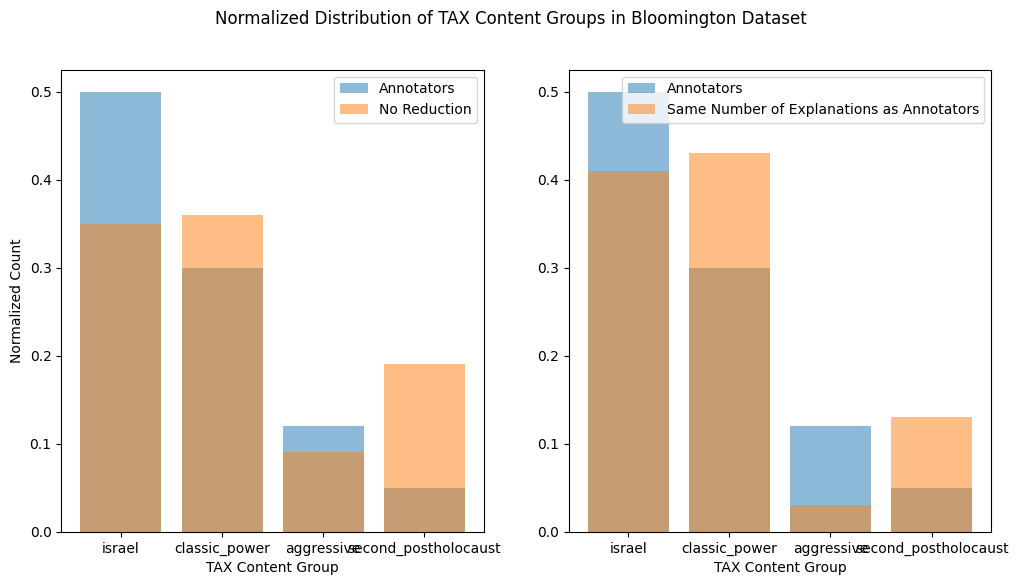

In [54]:
plot_distribution_diff_pair(
    b_tax_groups_count_norm,
    b_tax_e_groups_count_norm,
    b_tax_e_groups_same_count_norm,
    'No Reduction',
    'Same Number of Explanations as Annotators',
    'Normalized Distribution of TAX Content Groups in Bloomington Dataset',
    'TAX Content Group',
    normalized=True)

In [55]:
compute_multilabel_prec_recall(bloomington_tax, 'annotators_content_groups', 'explanation_content_groups')

,content_group,annotators_identified,model_identified,both_identified,recall,precision
0,aggressive,208,220,73,0.350962,0.331818
3,classic_power,493,860,440,0.892495,0.511628
2,israel,841,840,769,0.914388,0.915476
1,second_postholocaust,84,452,62,0.738095,0.137168


### TAX EX

In [58]:
bloomington_tax_ex = bloomington[bloomington['TAX_EX_c']=='Yes'][BLOOMINGTON_DATA_COLS + ['TAX_EX_e_chapters']]
bloomington_tax_ex['annotators_content_groups'] = bloomington_tax_ex['ihra_sections'].apply(lambda x: list(set([group_ihra_content(item) for item in x])))
bloomington_tax_ex['explanation_content_groups'] = bloomington_tax_ex['TAX_EX_e_chapters'].map(group_lexicon_content)
bloomington_tax_ex.head()

bloomington_tax_ex['overlap'] = bloomington_tax_ex.apply(
    lambda row: 1 if set(row['annotators_content_groups']) & set(row['explanation_content_groups']) else 0,
    axis=1
)
bloomington_tax_ex['overlap'].mean()

np.float64(0.8865248226950354)

In [59]:
bloomington_tax_ex["ihra_sections_cnt"] = bloomington_tax_ex["ihra_sections"].map(len)
bloomington_tax_ex["tax_ex_e_chapters_cnt"] = bloomington_tax_ex["TAX_EX_e_chapters"].map(len)

In [60]:
b_tax_ex_sections_count, b_tax_ex_sections_count_norm = count_items(bloomington_tax_ex["ihra_sections"])

In [61]:
sum(b_tax_ex_sections_count.values())

1724

In [62]:
b_tax_ex_e_chapters_count, b_tax_ex_e_chapters_count_norm = count_items(bloomington_tax_ex["TAX_EX_e_chapters"])

In [63]:
def reduce_to_same_number(row, to_reduce_col, reference_col):
    if len(row[to_reduce_col]) > 0:
        if row[reference_col] == len(row[to_reduce_col]):
            return row[to_reduce_col]
        else:
            return row[to_reduce_col][:row[reference_col]]
    else:
        return row[to_reduce_col]


In [64]:
bloomington_tax_ex["TAX_EX_e_chapters_max_2"] = bloomington_tax_ex["TAX_EX_e_chapters"].map(lambda x: [x[0], x[1] ] if len(x)>2 else x)
bloomington_tax_ex["TAX_EX_e_chapters_max_2_cnt"] = bloomington_tax_ex["TAX_EX_e_chapters_max_2"].map(len)
bloomington_tax_ex["TAX_EX_e_chapters_same"] = bloomington_tax_ex.apply(lambda x: reduce_to_same_number(x, to_reduce_col="TAX_EX_e_chapters", reference_col="ihra_sections_cnt"), axis=1)
bloomington_tax_ex["TAX_EX_e_chapters_same_cnt"] = bloomington_tax_ex["TAX_EX_e_chapters_same"].map(len)
bloomington_tax_ex[["ihra_sections_cnt", "tax_ex_e_chapters_cnt", "TAX_EX_e_chapters_max_2_cnt", "TAX_EX_e_chapters_same_cnt"]].describe()

,ihra_sections_cnt,tax_ex_e_chapters_cnt,TAX_EX_e_chapters_max_2_cnt,TAX_EX_e_chapters_same_cnt
count,1269.000000,1269.000000,1269.000000,1269.000000
mean,1.358550,2.486210,1.856580,1.319149
std,0.479764,0.994864,0.350639,0.466331
min,1.000000,1.000000,1.000000,1.000000
25%,1.000000,2.000000,2.000000,1.000000
50%,1.000000,2.000000,2.000000,1.000000
75%,2.000000,3.000000,2.000000,2.000000
max,2.000000,7.000000,2.000000,2.000000


In [ ]:
bloomington_tax_ex['explanation_same_content_groups'] = bloomington_tax_ex['TAX_EX_e_chapters_same'].map(group_lexicon_content)

In [ ]:
b_tax_ex_groups_count, b_tax_ex_groups_count_norm = count_items(bloomington_tax_ex["annotators_content_groups"], interpret_as_int=False)
b_tax_ex_e_groups_count, b_tax_ex_e_groups_count_norm = count_items(bloomington_tax_ex["explanation_content_groups"], interpret_as_int=False)
b_tax_ex_e_groups_same_count, b_tax_ex_e_groups_same_count_norm = count_items(bloomington_tax_ex["explanation_same_content_groups"], interpret_as_int=False)

In [67]:
b_tax_ex_groups_count

Counter({'israel': 769,
         'classic_power': 477,
         'aggressive': 209,
         'second_postholocaust': 81,
         None: 40})

In [68]:
b_tax_ex_groups_count = {key: value for key, value in b_tax_groups_count.items() if key in ALL_GROUPS}
b_tax_ex_groups_count_norm = {key: value for key, value in b_tax_groups_count_norm.items() if key in ALL_GROUPS}

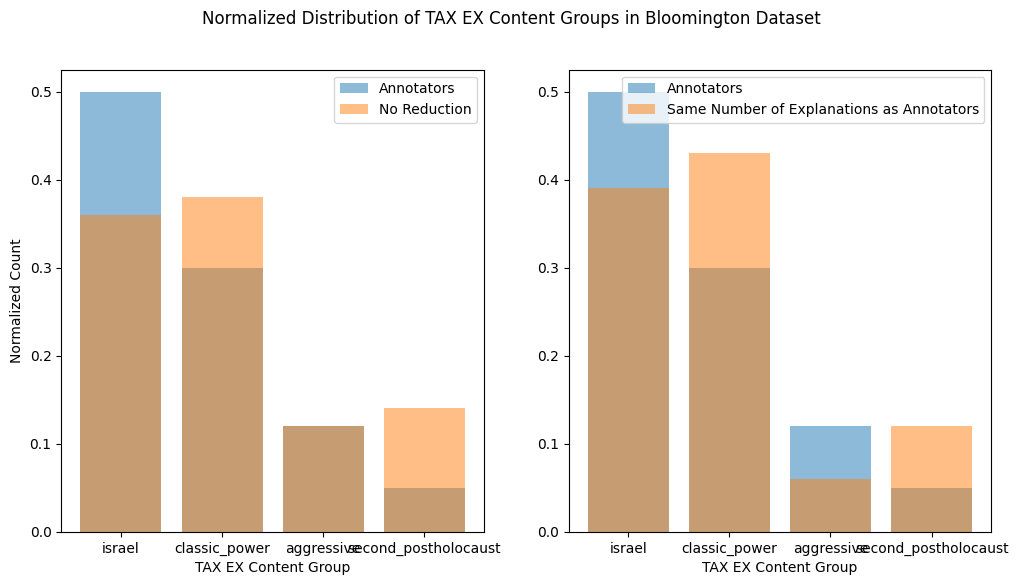

In [72]:
plot_distribution_diff_pair(
    b_tax_ex_groups_count_norm,
    b_tax_ex_e_groups_count_norm,
    b_tax_ex_e_groups_same_count_norm,
    'No Reduction',
    'Same Number of Explanations as Annotators',
    'Normalized Distribution of TAX EX Content Groups in Bloomington Dataset',
    'TAX EX Content Group',
    normalized=True)

In [73]:
compute_multilabel_prec_recall(bloomington_tax_ex, 'annotators_content_groups', 'explanation_content_groups')

,content_group,annotators_identified,model_identified,both_identified,recall,precision
0,aggressive,209,240,94,0.449761,0.391667
3,classic_power,477,758,406,0.851153,0.535620
2,israel,769,716,665,0.864759,0.928771
1,second_postholocaust,81,270,47,0.580247,0.174074


# Decoding

In [76]:
d_chapters_count, d_chapters_count_norm = count_items(decoding["comment_codes_all_chapters"])
sum(d_chapters_count.values())/len(decoding)

1.4783338931810548

### IHRA

Can be compared on the level of groups only

In [78]:
decoding_ihra = decoding[decoding['IHRA_c']=='Yes'][DECODING_DATA_COLS + ['IHRA_e', 'IHRA_e_sections']]

In [79]:
decoding_ihra = decoding[decoding['IHRA_c']=='Yes'][DECODING_DATA_COLS + ['IHRA_e', 'IHRA_e_sections']]
decoding_ihra['annotators_content_groups'] = decoding_ihra['comment_codes_all_chapters'].apply(group_lexicon_content)
decoding_ihra['explanation_content_groups'] = decoding_ihra['IHRA_e_sections'].apply(lambda x: list(set([group_ihra_content(item) for item in x])))
decoding_ihra.tail()

decoding_ihra['overlap'] = decoding_ihra.apply(
    lambda row: 1 if set(row['annotators_content_groups']) & set(row['explanation_content_groups']) else 0,
    axis=1
)
decoding_ihra['overlap'].mean()

np.float64(0.8161898965307365)

In [80]:
decoding_ihra["lexicon_chapters_cnt"] = decoding_ihra["comment_codes_all_chapters"].map(len)
decoding_ihra["IHRA_e_sections_cnt"] = decoding_ihra["IHRA_e_sections"].map(len)

In [81]:
d_ihra_chapters_count, d_ihra_chapters_count_norm = count_items(decoding_ihra["comment_codes_all_chapters"])
#sum(d_ihra_chapters_count.values())

In [82]:
d_ihra_e_sections_count, d_ihra_e_sections_count_norm = count_items(decoding_ihra["IHRA_e_sections"])

In [83]:
decoding_ihra["IHRA_e_sections_max_2"] = decoding_ihra["IHRA_e_sections"].map(lambda x: [x[0], x[1] ] if len(x)>2 else x)
decoding_ihra["IHRA_e_sections_max_2_cnt"] = decoding_ihra["IHRA_e_sections_max_2"].map(len)
decoding_ihra["IHRA_e_sections_same"] = decoding_ihra.apply(lambda x: reduce_to_same_number(x, to_reduce_col="IHRA_e_sections", reference_col="lexicon_chapters_cnt"), axis=1)
decoding_ihra["IHRA_e_sections_same_cnt"] = decoding_ihra["IHRA_e_sections_same"].map(len)
decoding_ihra[["lexicon_chapters_cnt", "IHRA_e_sections_cnt", "IHRA_e_sections_max_2_cnt", "IHRA_e_sections_same_cnt"]].describe()

,lexicon_chapters_cnt,IHRA_e_sections_cnt,IHRA_e_sections_max_2_cnt,IHRA_e_sections_same_cnt
count,1643.000000,1643.000000,1643.000000,1643.000000
mean,1.522215,2.071211,1.760195,1.339014
std,0.894543,0.786870,0.427094,0.617532
min,0.000000,1.000000,1.000000,0.000000
25%,1.000000,2.000000,2.000000,1.000000
50%,1.000000,2.000000,2.000000,1.000000
75%,2.000000,3.000000,2.000000,2.000000
max,8.000000,6.000000,2.000000,5.000000


In [ ]:
decoding_ihra['explanation_same_content_groups'] = decoding_ihra['IHRA_e_sections_same'].apply(lambda x: list(set([group_ihra_content(item) for item in x])))

In [ ]:
d_ihra_groups_count, d_ihra_groups_count_norm = count_items(decoding_ihra["annotators_content_groups"], interpret_as_int=False)
d_ihra_e_groups_count, d_ihra_e_groups_count_norm = count_items(decoding_ihra["explanation_content_groups"], interpret_as_int=False)
d_ihra_e_groups_same_count, d_ihra_e_groups_same_count_norm = count_items(decoding_ihra["explanation_same_content_groups"], interpret_as_int=False)

In [90]:
d_ihra_e_groups_count = {key: value for key, value in d_ihra_e_groups_count.items() if key in ALL_GROUPS}
d_ihra_e_groups_count_norm = {key: value for key, value in d_ihra_e_groups_count_norm.items() if key in ALL_GROUPS}

d_ihra_e_groups_same_count = {key: value for key, value in d_ihra_e_groups_same_count.items() if key in ALL_GROUPS}
d_ihra_e_groups_same_count_norm = {key: value for key, value in d_ihra_e_groups_same_count_norm.items() if key in ALL_GROUPS}

In [93]:
compute_multilabel_prec_recall(decoding_ihra, 'annotators_content_groups', 'explanation_content_groups')

,content_group,annotators_identified,model_identified,both_identified,recall,precision
0,aggressive,87,178,44,0.505747,0.247191
3,classic_power,799,914,571,0.714643,0.624726
2,israel,934,1071,793,0.849036,0.740430
1,second_postholocaust,224,746,102,0.455357,0.136729


### TAX

In [96]:
decoding_tax = decoding[decoding['TAX_c']=='Yes'][DECODING_DATA_COLS + ['TAX_e', 'TAX_e_chapters', 'TAX_e_chapters_no', 'TAX_e_sections']]
decoding_tax['annotators_content_groups'] = decoding_tax['comment_codes_all_chapters'].map(group_lexicon_content)
decoding_tax['explanation_content_groups'] = decoding_tax['TAX_e_chapters'].map(group_lexicon_content)
decoding_tax.head()

decoding_tax['overlap'] = decoding_tax.apply(
    lambda row: 1 if set(row['annotators_content_groups']) & set(row['explanation_content_groups']) else 0,
    axis=1
)
decoding_tax['overlap'].mean()

np.float64(0.8724696356275303)

In [97]:
decoding_tax["tax_chapters_cnt"] = decoding_tax["comment_codes_all_chapters"].map(len)
decoding_tax["tax_e_chapters_cnt"] = decoding_tax["TAX_e_chapters"].map(len)
decoding_tax[["tax_chapters_cnt", "tax_e_chapters_cnt"]].describe()

,tax_chapters_cnt,tax_e_chapters_cnt
count,1976.000000,1976.000000
mean,1.495951,3.235830
std,0.867987,1.422087
min,0.000000,1.000000
25%,1.000000,2.000000
50%,1.000000,3.000000
75%,2.000000,4.000000
max,8.000000,11.000000


In [98]:
d_tax_chapters_count, d_tax_chapters_count_norm = count_items(decoding_tax["comment_codes_all_chapters"])
sum(d_tax_chapters_count.values())

2956

#### Group level

In [ ]:
decoding_tax['explanation_same_content_groups'] = decoding_tax['TAX_e_chapters_same'].map(group_lexicon_content)

In [ ]:
d_tax_groups_count, d_tax_groups_count_norm = count_items(decoding_tax["annotators_content_groups"], interpret_as_int=False)
d_tax_e_groups_count, d_tax_e_groups_count_norm = count_items(decoding_tax["explanation_content_groups"], interpret_as_int=False)
d_tax_e_groups_same_count, d_tax_e_groups_same_count_norm = count_items(decoding_tax["explanation_same_content_groups"], interpret_as_int=False)

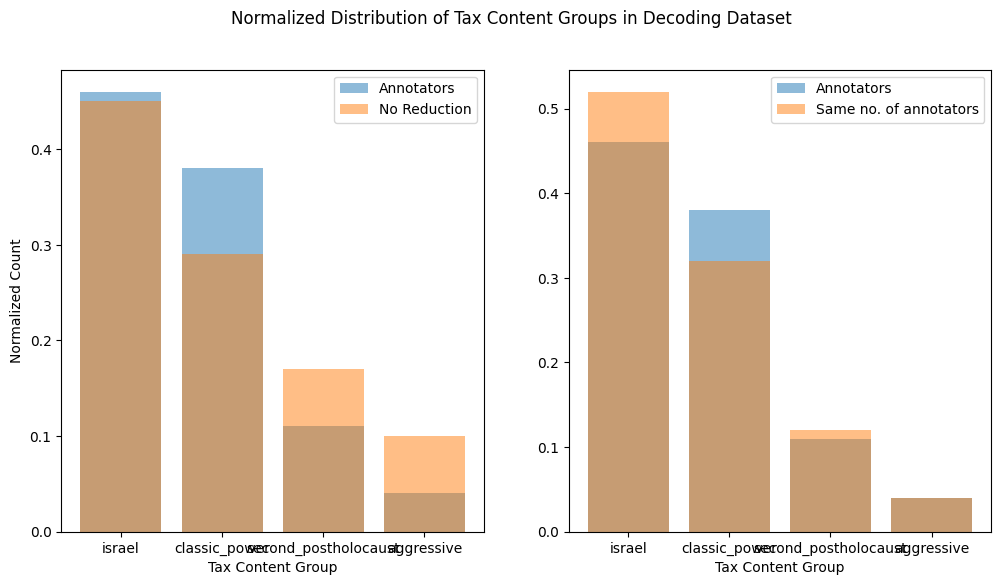

In [125]:
plot_distribution_diff_pair(
    d_tax_groups_count_norm,
    d_tax_e_groups_count_norm,
    d_tax_e_groups_same_count_norm,
    'No Reduction',
    'Same no. of annotators',
    'Normalized Distribution of Tax Content Groups in Decoding Dataset',
    'Tax Content Group',
    normalized=True)

In [126]:
compute_multilabel_prec_recall(decoding_tax, 'annotators_content_groups', 'explanation_content_groups')

,content_group,annotators_identified,model_identified,both_identified,recall,precision
0,aggressive,96,356,61,0.635417,0.171348
3,classic_power,939,997,634,0.675186,0.635908
2,israel,1134,1549,1082,0.954145,0.698515
1,second_postholocaust,275,578,177,0.643636,0.306228


### TAX_EX

In [130]:
decoding_tax_ex = decoding[decoding['TAX_EX_c']=='Yes'][DECODING_DATA_COLS + ['TAX_EX_e', 'TAX_EX_e_chapters', 'TAX_EX_e_chapters_no', 'TAX_EX_e_sections']]
decoding_tax_ex['annotators_content_groups'] = decoding_tax_ex['comment_codes_all_chapters'].map(group_lexicon_content)
decoding_tax_ex['explanation_content_groups'] = decoding_tax_ex['TAX_EX_e_chapters'].map(group_lexicon_content)
decoding_tax_ex.head()

decoding_tax_ex['overlap'] = decoding_tax_ex.apply(
    lambda row: 1 if set(row['annotators_content_groups']) & set(row['explanation_content_groups']) else 0,
    axis=1
)
decoding_tax_ex['overlap'].mean()

np.float64(0.8722316865417377)

In [131]:
decoding_tax_ex["tax_ex_chapters_cnt"] = decoding_tax_ex["comment_codes_all_chapters"].map(len)
decoding_tax_ex["tax_ex_e_chapters_cnt"] = decoding_tax_ex["TAX_EX_e_chapters"].map(len)
decoding_tax_ex[["tax_ex_chapters_cnt", "tax_ex_e_chapters_cnt"]].describe()

,tax_ex_chapters_cnt,tax_ex_e_chapters_cnt
count,1761.000000,1761.000000
mean,1.516184,2.622374
std,0.893725,1.257676
min,0.000000,1.000000
25%,1.000000,2.000000
50%,1.000000,2.000000
75%,2.000000,3.000000
max,8.000000,11.000000


In [132]:
d_tax_ex_chapters_count, d_tax_ex_chapters_count_norm = count_items(decoding_tax_ex["comment_codes_all_chapters"])
sum(d_tax_ex_chapters_count.values())

2670

#### Group level

In [ ]:
decoding_tax_ex['explanation_same_content_groups'] = decoding_tax_ex['TAX_EX_e_chapters_same'].map(group_lexicon_content)

In [ ]:
d_tax_ex_groups_count, d_tax_ex_groups_count_norm = count_items(decoding_tax_ex["annotators_content_groups"], interpret_as_int=False)
d_tax_ex_e_groups_count, d_tax_ex_e_groups_count_norm = count_items(decoding_tax_ex["explanation_content_groups"], interpret_as_int=False)
d_tax_ex_e_groups_same_count, d_tax_ex_e_groups_same_count_norm = count_items(decoding_tax_ex["explanation_same_content_groups"], interpret_as_int=False)

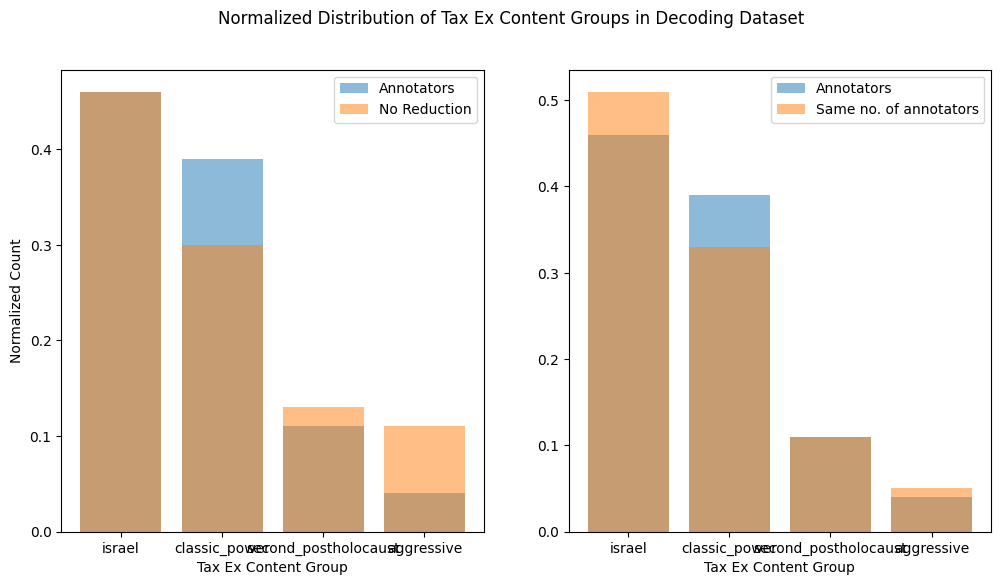

In [159]:
plot_distribution_diff_pair(
    d_tax_ex_groups_count_norm,
    d_tax_ex_e_groups_count_norm,
    d_tax_ex_e_groups_same_count_norm,
    'No Reduction',
    'Same no. of annotators',
    'Normalized Distribution of Tax Ex Content Groups in Decoding Dataset',
    'Tax Ex Content Group',
    normalized=True)

In [160]:
compute_multilabel_prec_recall(decoding_tax_ex, 'annotators_content_groups', 'explanation_content_groups')

,content_group,annotators_identified,model_identified,both_identified,recall,precision
0,aggressive,94,320,64,0.680851,0.200000
3,classic_power,841,839,571,0.678954,0.680572
2,israel,1008,1293,944,0.936508,0.730085
1,second_postholocaust,241,351,146,0.605809,0.415954


# DATASET UNION

## IHRA

In [164]:
bloomington_ihra = bloomington[bloomington['IHRA_c']=='Yes'][BLOOMINGTON_DATA_COLS + ['IHRA_e', 'IHRA_e_sections']]
bloomington_ihra["ihra_sections"] = bloomington_ihra["ihra_sections"].map(lambda x: [i for i in x if i!=13])  # Remove section 13 as it is not part of the IHRA definition (errors in section-level annotations)
print(bloomington_ihra["ihra_sections"].value_counts())
bloomington_ihra['annotators_content_groups'] = bloomington_ihra['ihra_sections'].apply(lambda x: list(set([group_ihra_content(item) for item in x])))
bloomington_ihra['explanation_content_groups'] = bloomington_ihra['IHRA_e_sections'].apply(lambda x: list(set([group_ihra_content(item) for item in x])))
bloomington_ihra["dataset_id"] = "b"
bloomington_ihra = bloomington_ihra[["comment_cleaned", "annotators_content_groups", "IHRA_e", "explanation_content_groups", "dataset_id"]]

decoding_ihra = decoding[decoding['IHRA_c']=='Yes'][DECODING_DATA_COLS + ['IHRA_e', 'IHRA_e_sections']]
decoding_ihra['annotators_content_groups'] = decoding_ihra['comment_codes_all_chapters'].apply(group_lexicon_content)
decoding_ihra['explanation_content_groups'] = decoding_ihra['IHRA_e_sections'].apply(lambda x: list(set([group_ihra_content(item) for item in x])))
decoding_ihra["dataset_id"] = "d"
decoding_ihra = decoding_ihra[["comment_cleaned", "annotators_content_groups", "IHRA_e", "explanation_content_groups", "dataset_id"]]

# Now union — both dataframes already have annotators_content_groups
df_union_ihra = pd.concat([bloomington_ihra, decoding_ihra], ignore_index=True)
df_union_ihra.sample(2)


ihra_sections
[2]         295
[7]         181
[10]        163
[2, 10]      79
[0]          77
[10, 7]      69
[0, 10]      61
[9]          53
[4]          22
[9, 7]       22
[2, 3]       17
[10, 11]     16
[0, 2]       16
[1]          16
[10, 2]      14
[2, 7]       13
[3]          12
[8, 7]        9
[11, 7]       7
[11]          7
[0, 1]        7
[9, 10]       7
[1, 2]        7
[]            6
[2, 4]        6
[6]           5
[1, 10]       5
[9, 2]        5
[0, 7]        5
[2, 6]        4
[2, 11]       4
[10, 6]       3
[10, 4]       3
[2, 5]        3
[8]           3
[3, 7]        3
[0, 9]        3
[1, 7]        2
[10, 3]       2
[10, 5]       2
[1, 11]       2
[5]           2
[0, 4]        2
[4, 5]        2
[9, 6]        1
[8, 9]        1
[1, 4]        1
[9, 11]       1
[3, 11]       1
[4, 7]        1
[6, 7]        1
[0, 3]        1
[0, 6]        1
[8, 10]       1
Name: count, dtype: int64


,comment_cleaned,annotators_content_groups,IHRA_e,explanation_content_groups,dataset_id
1360,Netanyahu you are old enough to die...why are ...,[aggressive],"The post contains antisemitic speech, as it ca...","[second_postholocaust, israel]",d
2595,Pauline why israelis don’t want to be part of ...,"[second_postholocaust, israel]","The post contains antisemitic speech, as it im...","[second_postholocaust, israel]",d


In [165]:
df_union_ihra['overlap'] = df_union_ihra.apply(
    lambda row: 1 if set(row['annotators_content_groups']) & set(row['explanation_content_groups']) else 0,
    axis=1
)
df_union_ihra['overlap'].mean()



np.float64(0.842832469775475)

In [166]:
df_union_ihra["annotator_content_cnt"] = df_union_ihra["annotators_content_groups"].map(len)
df_union_ihra["model_content_count"] = df_union_ihra["explanation_content_groups"].map(len)
df_union_ihra[["annotator_content_cnt", "model_content_count"]].describe()

,annotator_content_cnt,model_content_count
count,2895.000000,2895.000000
mean,1.230052,1.653541
std,0.477115,0.658132
min,0.000000,1.000000
25%,1.000000,1.000000
50%,1.000000,2.000000
75%,1.000000,2.000000
max,3.000000,4.000000


#### Group level

In [167]:
u_ihra_groups_count, u_ihra_groups_count_norm = count_items(df_union_ihra["annotators_content_groups"], interpret_as_int=False)
u_ihra_e_groups_count, u_ihra_e_groups_count_norm = count_items(df_union_ihra["explanation_content_groups"], interpret_as_int=False)

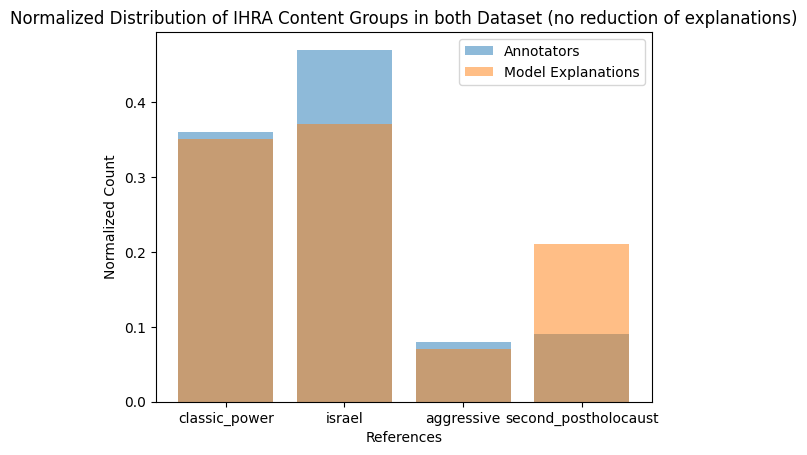

In [168]:
plot_distribution_diff(
    u_ihra_groups_count_norm, 
    u_ihra_e_groups_count_norm, 
    'Normalized Distribution of IHRA Content Groups in both Dataset (no reduction of explanations)', 
    normalized=True)

Calculate recall (how often did the model correctly identify a specific content group that was labeled by annotators) as well as precision (how often did the model correctly name the content group as an explanation of a post being antisemitic)

In [169]:
compute_multilabel_prec_recall(df_union_ihra, 'annotators_content_groups', 'explanation_content_groups')

,content_group,annotators_identified,model_identified,both_identified,recall,precision
0,aggressive,293,322,117,0.399317,0.363354
3,classic_power,1292,1663,984,0.761610,0.591702
2,israel,1670,1785,1447,0.866467,0.810644
1,second_postholocaust,306,1017,151,0.493464,0.148476


## TAX

In [170]:
bloomington_tax = bloomington[bloomington['TAX_c']=='Yes'][BLOOMINGTON_DATA_COLS + ['TAX_e', 'TAX_e_chapters']]
bloomington_tax['annotators_content_groups'] = bloomington_tax['ihra_sections'].apply(lambda x: list(set([group_ihra_content(item) for item in x if item!=13])))  # Remove section 13 as it is not part of the IHRA definition (errors in section-level annotations)
bloomington_tax['explanation_content_groups'] = bloomington_tax['TAX_e_chapters'].map(group_lexicon_content)
bloomington_tax["dataset_id"] = "b"
bloomington_tax = bloomington_tax[["comment_cleaned", "annotators_content_groups", "TAX_e", "explanation_content_groups", "dataset_id"]]

decoding_tax = decoding[decoding['TAX_c']=='Yes'][DECODING_DATA_COLS + ['TAX_e', 'TAX_e_chapters', 'TAX_e_chapters_no', 'TAX_e_sections']]
decoding_tax['annotators_content_groups'] = decoding_tax['comment_codes_all_chapters'].map(group_lexicon_content)
decoding_tax['explanation_content_groups'] = decoding_tax['TAX_e_chapters'].map(group_lexicon_content)
decoding_tax["dataset_id"] = "d"
decoding_tax = decoding_tax[["comment_cleaned", "annotators_content_groups", "TAX_e", "explanation_content_groups", "dataset_id"]]

# Now union — both dataframes already have annotators_content_groups
df_union_tax = pd.concat([bloomington_tax, decoding_tax], ignore_index=True)
df_union_tax.sample(2)

,comment_cleaned,annotators_content_groups,TAX_e,explanation_content_groups,dataset_id
1117,You are trash You racist Zionazi!!,[israel],"This text contains antisemitic content, specif...","[israel, aggressive]",b
1925,"STUDY Zionist policy, study International Law,...","[israel, classic_power]",The text compares Israel to a 'concentration c...,"[second_postholocaust, israel]",d


In [172]:
bloomington_tax['annotators_content_groups'].value_counts()

annotators_content_groups
[israel]                                 611
[classic_power]                          335
[israel, classic_power]                  121
[aggressive]                             102
[israel, aggressive]                      78
[second_postholocaust]                    36
[second_postholocaust, israel]            31
[classic_power, aggressive]               24
[second_postholocaust, classic_power]     13
[]                                         6
[second_postholocaust, aggressive]         4
Name: count, dtype: int64

In [173]:
df_union_tax['overlap'] = df_union_tax.apply(
    lambda row: 1 if set(row['annotators_content_groups']) & set(row['explanation_content_groups']) else 0,
    axis=1
)
df_union_tax['overlap'].mean()

np.float64(0.8822295474977525)

In [174]:
df_union_tax["annotator_content_cnt"] = df_union_tax["annotators_content_groups"].map(len)
df_union_tax["model_content_count"] = df_union_tax["explanation_content_groups"].map(len)
df_union_tax[["annotator_content_cnt", "model_content_count"]].describe()

,annotator_content_cnt,model_content_count
count,3337.000000,3337.000000
mean,1.219658,1.753671
std,0.469703,0.769533
min,0.000000,1.000000
25%,1.000000,1.000000
50%,1.000000,2.000000
75%,1.000000,2.000000
max,3.000000,4.000000


#### Group level

In [175]:
u_tax_groups_count, u_tax_groups_count_norm = count_items(df_union_tax["annotators_content_groups"], interpret_as_int=False)
u_tax_e_groups_count, u_tax_e_groups_count_norm = count_items(df_union_tax["explanation_content_groups"], interpret_as_int=False)
print(u_tax_groups_count)
print(u_tax_e_groups_count)

Counter({'israel': 1975, 'classic_power': 1432, 'second_postholocaust': 359, 'aggressive': 304})
Counter({'israel': 2389, 'classic_power': 1857, 'second_postholocaust': 1030, 'aggressive': 576})


In [176]:
# get all unique items across all lists
all_items = set(item for sublist in df_union_tax["annotators_content_groups"] if isinstance(sublist, list) for item in sublist)
print(all_items)

{'aggressive', 'second_postholocaust', 'israel', 'classic_power'}


In [177]:
for item in all_items:
    result = group_ihra_content(item)  # or group_lexicon_content, whichever is relevant here
    if result is None:
        print(f"Input '{item}' maps to None")

Input 'aggressive' maps to None
Input 'second_postholocaust' maps to None
Input 'israel' maps to None
Input 'classic_power' maps to None


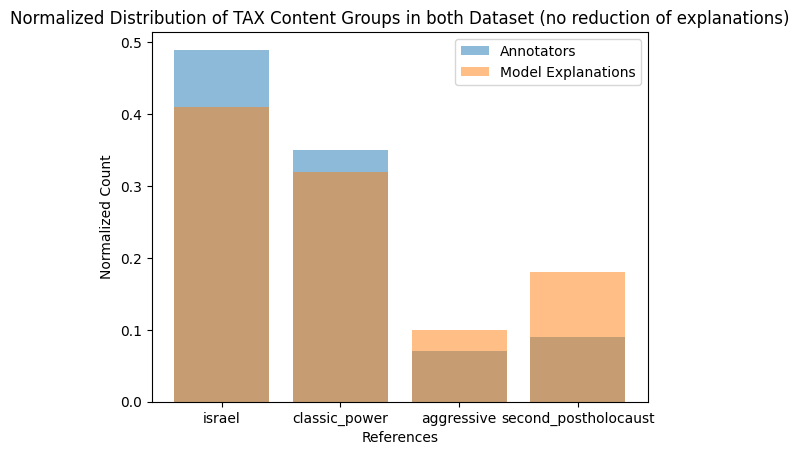

In [178]:
plot_distribution_diff(
    u_tax_groups_count_norm, 
    u_tax_e_groups_count_norm, 
    'Normalized Distribution of TAX Content Groups in both Dataset (no reduction of explanations)', 
    normalized=True)

Calculate recall (how often did the model correctly identify a specific content group that was labeled by annotators) as well as precision (how often did the model correctly name the content group as an explanation of a post being antisemitic)

In [179]:
compute_multilabel_prec_recall(df_union_tax, 'annotators_content_groups', 'explanation_content_groups')

,content_group,annotators_identified,model_identified,both_identified,recall,precision
0,aggressive,304,576,134,0.440789,0.232639
3,classic_power,1432,1857,1074,0.750000,0.578352
2,israel,1975,2389,1851,0.937215,0.774801
1,second_postholocaust,359,1030,239,0.665738,0.232039


## TAX_EX

In [180]:
bloomington_tax_ex = bloomington[bloomington['TAX_EX_c']=='Yes'][BLOOMINGTON_DATA_COLS + ['TAX_EX_e', 'TAX_EX_e_chapters']]
bloomington_tax_ex['annotators_content_groups'] = bloomington_tax_ex['ihra_sections'].apply(lambda x: list(set([group_ihra_content(item) for item in x if item!=13])))  # Remove section 13 as it is not part of the IHRA definition (errors in section-level annotations)
bloomington_tax_ex['explanation_content_groups'] = bloomington_tax_ex['TAX_EX_e_chapters'].map(group_lexicon_content)
bloomington_tax_ex["dataset_id"] = "b"
bloomington_tax_ex = bloomington_tax_ex[["comment_cleaned", "annotators_content_groups", "TAX_EX_e", "explanation_content_groups", "dataset_id"]]

decoding_tax_ex = decoding[decoding['TAX_EX_c']=='Yes'][DECODING_DATA_COLS + ['TAX_EX_e', 'TAX_EX_e_chapters', 'TAX_EX_e_chapters_no', 'TAX_EX_e_sections']]
decoding_tax_ex['annotators_content_groups'] = decoding_tax_ex['comment_codes_all_chapters'].map(group_lexicon_content)
decoding_tax_ex['explanation_content_groups'] = decoding_tax_ex['TAX_EX_e_chapters'].map(group_lexicon_content)
decoding_tax_ex["dataset_id"] = "d"
decoding_tax_ex = decoding_tax_ex[["comment_cleaned", "annotators_content_groups", "TAX_EX_e", "explanation_content_groups", "dataset_id"]]

# Now union — both dataframes already have annotators_content_groups
df_union_tax_ex = pd.concat([bloomington_tax_ex, decoding_tax_ex], ignore_index=True)
df_union_tax_ex.sample(2)

,comment_cleaned,annotators_content_groups,TAX_EX_e,explanation_content_groups,dataset_id
1774,Stop Licking 😈 🇮🇱 zionist Bolls,[classic_power],This text contains an insult (category 38: Ins...,[aggressive],d
53,Surprised? Not at all! Exporting terror is par...,[israel],This text can be classified as antisemitic bec...,"[israel, classic_power]",b


In [181]:
df_union_tax_ex['overlap'] = df_union_tax_ex.apply(
    lambda row: 1 if set(row['annotators_content_groups']) & set(row['explanation_content_groups']) else 0,
    axis=1
)
df_union_tax_ex['overlap'].mean()

np.float64(0.8782178217821782)

In [182]:
df_union_tax_ex["annotator_content_cnt"] = df_union_tax_ex["annotators_content_groups"].map(len)
df_union_tax_ex["model_content_count"] = df_union_tax_ex["explanation_content_groups"].map(len)
df_union_tax_ex[["annotator_content_cnt", "model_content_count"]].describe()

,annotator_content_cnt,model_content_count
count,3030.000000,3030.000000
mean,1.227723,1.579868
std,0.476891,0.666159
min,0.000000,1.000000
25%,1.000000,1.000000
50%,1.000000,1.000000
75%,1.000000,2.000000
max,3.000000,4.000000


#### Group level

In [183]:
u_tax_ex_groups_count, u_tax_ex_groups_count_norm = count_items(df_union_tax_ex["annotators_content_groups"], interpret_as_int=False)
u_tax_ex_e_groups_count, u_tax_ex_e_groups_count_norm = count_items(df_union_tax_ex["explanation_content_groups"], interpret_as_int=False)
print(u_tax_ex_groups_count)

Counter({'israel': 1777, 'classic_power': 1318, 'second_postholocaust': 322, 'aggressive': 303})


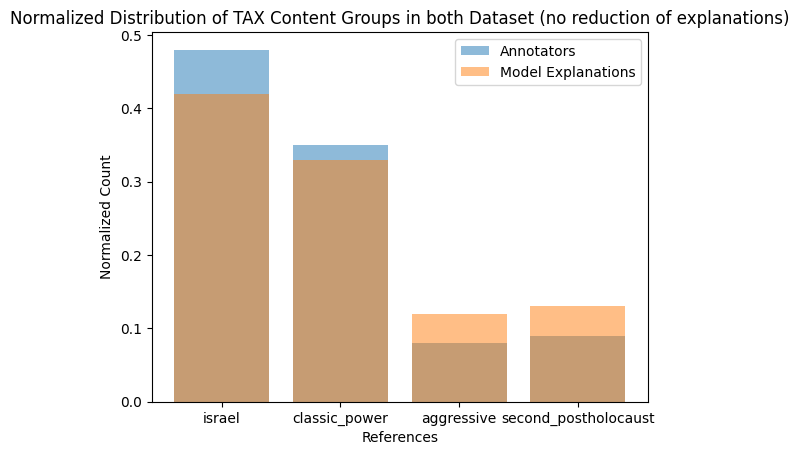

In [184]:
plot_distribution_diff(
    u_tax_ex_groups_count_norm, 
    u_tax_ex_e_groups_count_norm, 
    'Normalized Distribution of TAX Content Groups in both Dataset (no reduction of explanations)', 
    normalized=True)

Calculate recall (how often did the model correctly identify a specific content group that was labeled by annotators) as well as precision (how often did the model correctly name the content group as an explanation of a post being antisemitic)

In [185]:
compute_multilabel_prec_recall(df_union_tax_ex, 'annotators_content_groups', 'explanation_content_groups')

,content_group,annotators_identified,model_identified,both_identified,recall,precision
0,aggressive,303,560,158,0.521452,0.282143
3,classic_power,1318,1597,977,0.741275,0.611772
2,israel,1777,2009,1609,0.905459,0.800896
1,second_postholocaust,322,621,193,0.599379,0.310789
